In [1]:
from src.baseline_config import build_training_config
from src.phase2.config import PHASE2_RUNS
from src.phase2.experiment import (
    curate_phase2_kinf_dataset,
    ingest_phase2_confidence_only_dataset,
    ingest_phase2_dataset,
    print_phase2_detection_summary,
    print_phase2_source_summary,
    print_phase2_summary,
    print_phase2_train_summary,
    run_phase2_experiments,
    show_phase2_plots,
)
from utils.metrics import print_results_metrics_summary

TRAINING_CONFIG = build_training_config(architecture="vit_small")


In [2]:
print_phase2_source_summary()

histology
Adenoma                     1578
Sessile_serrated_adenoma     725
Hyperplastic                 334
Adenocarcinoma               101
total: 2738


In [ ]:
ingestion_summary = ingest_phase2_dataset()
ingestion_summary

In [3]:
curation_summary = curate_phase2_kinf_dataset()
curation_summary

{'source_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train.csv',
 'output_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train_kinf.csv',
 'confidence_threshold': 0.4,
 'total_rows': 6319,
 'original_rows': 2738,
 'video_rows': 3581,
 'dropped_video_rows': 1659}

In [5]:
print_phase2_train_summary()

histology
Adenoma                     2459
Sessile_serrated_adenoma    1926
Hyperplastic                1210
Adenocarcinoma               724
total: 6319


In [6]:
print_phase2_detection_summary()

               histology  total_images  annotated_images  unannotated_images  mean_annotated_confidence
                   TOTAL          6319              5517                 802                     0.6092
          Adenocarcinoma           724               705                  19                     0.6311
                 Adenoma          2459              2013                 446                     0.6117
            Hyperplastic          1210              1101                 109                     0.6159
Sessile_serrated_adenoma          1926              1698                 228                     0.5930


In [7]:
run_phase2_experiments(training_config=TRAINING_CONFIG, force_train=False)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_1\best_baseline_model.pth


c:\Users\luis\Documents\TFG - Data-Centric AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_3\best_baseline_model.pth


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase2\seed_4\best_baseline_model.pth


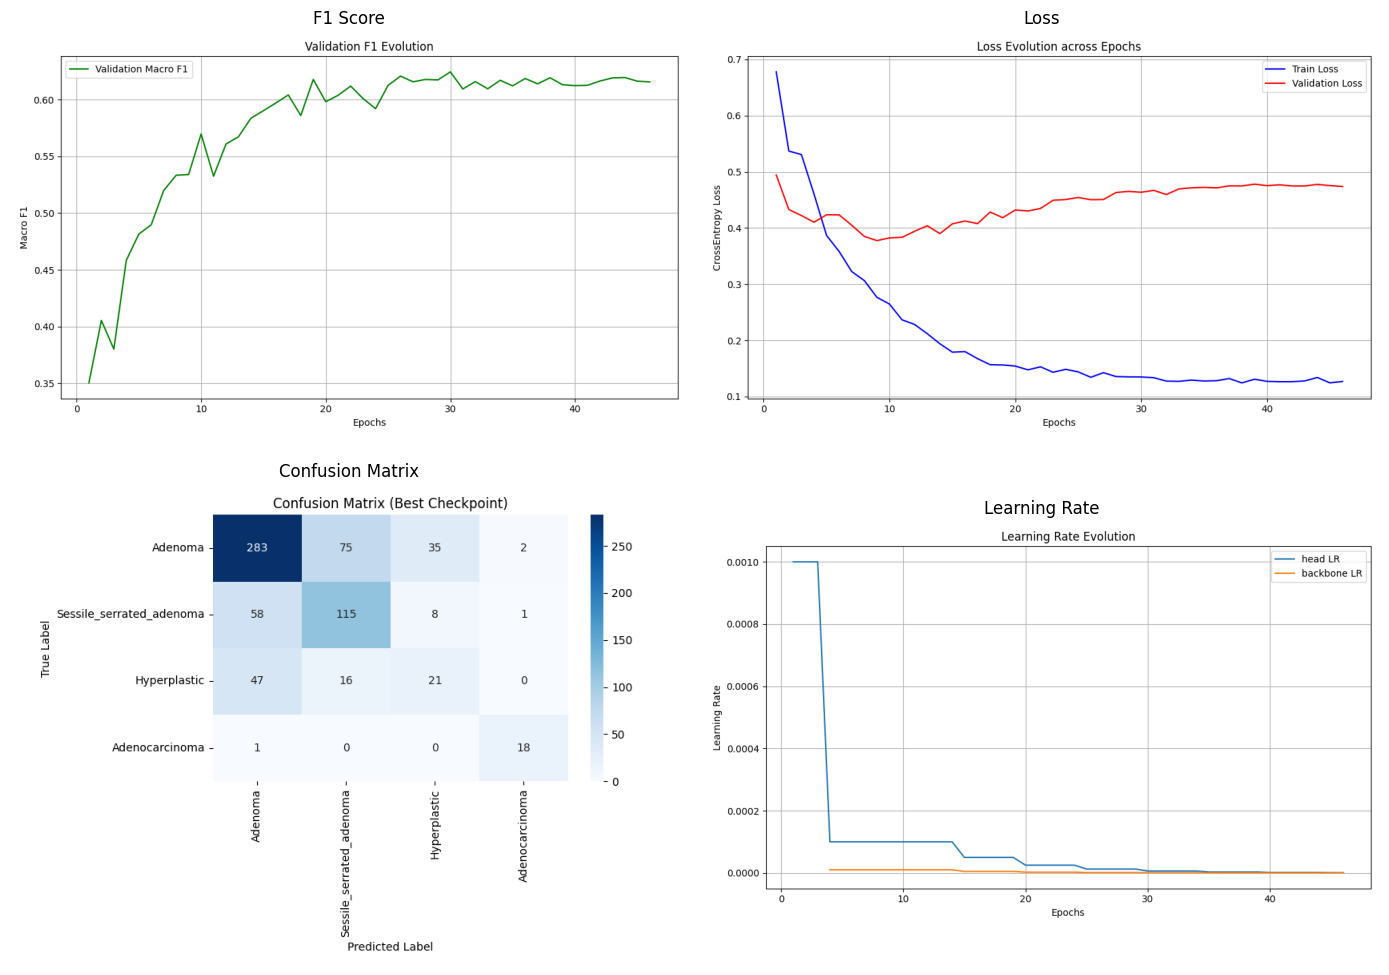

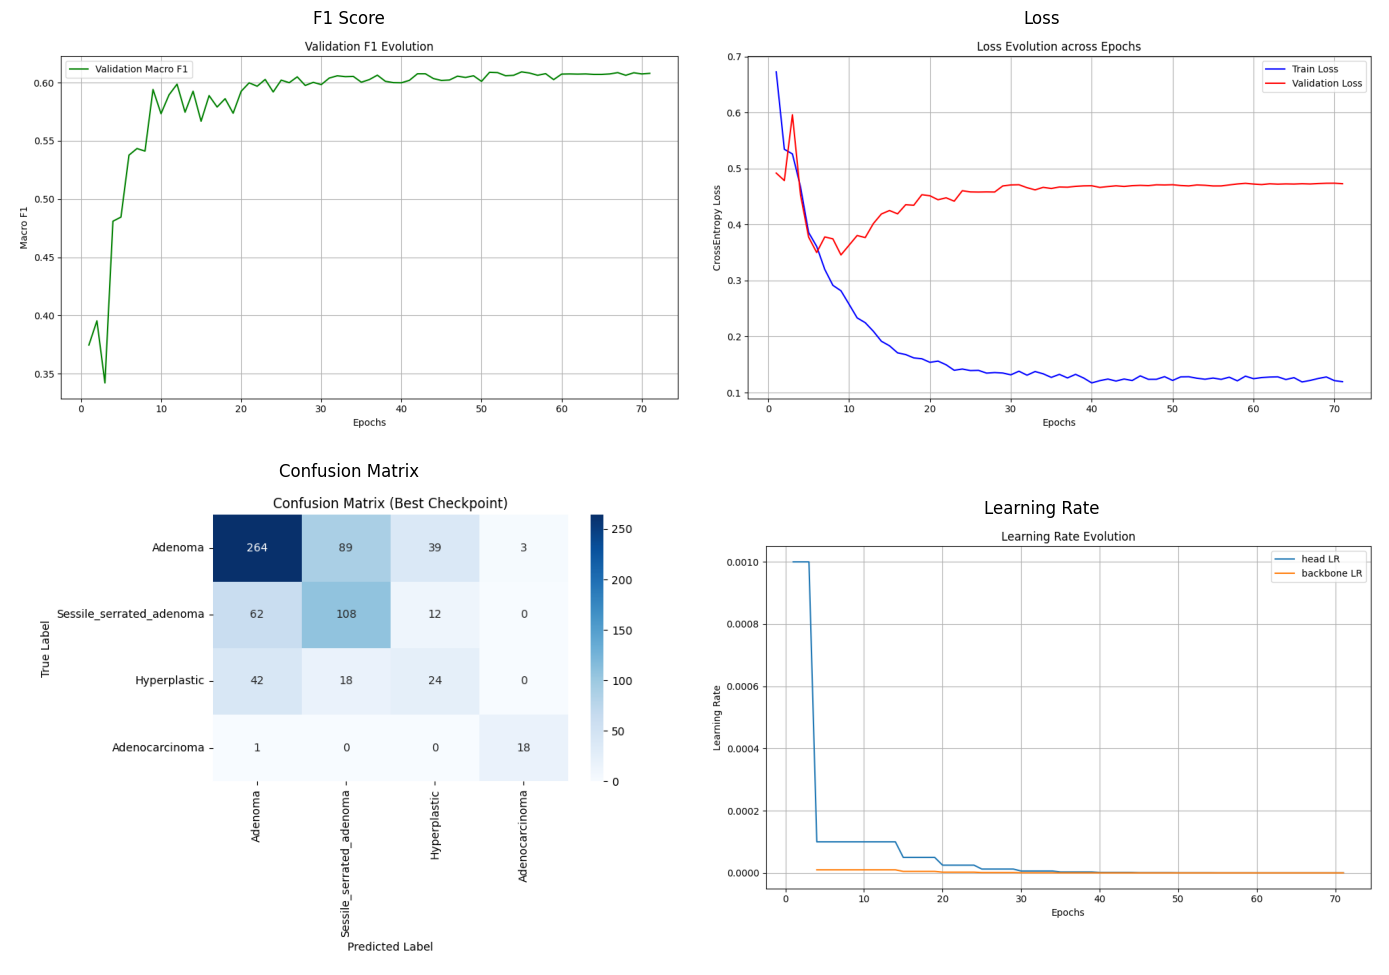

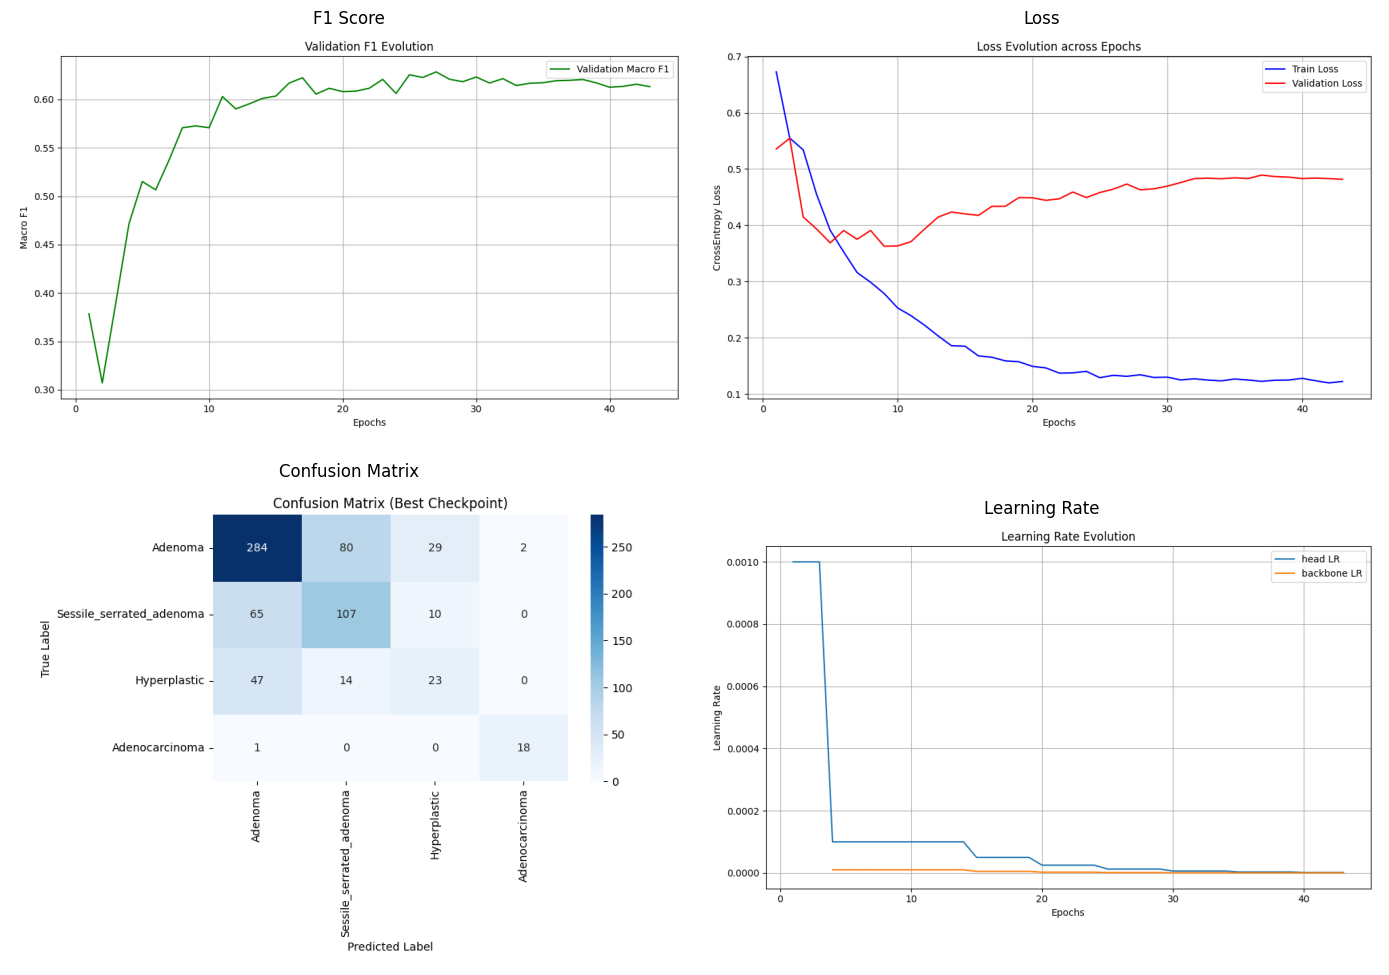

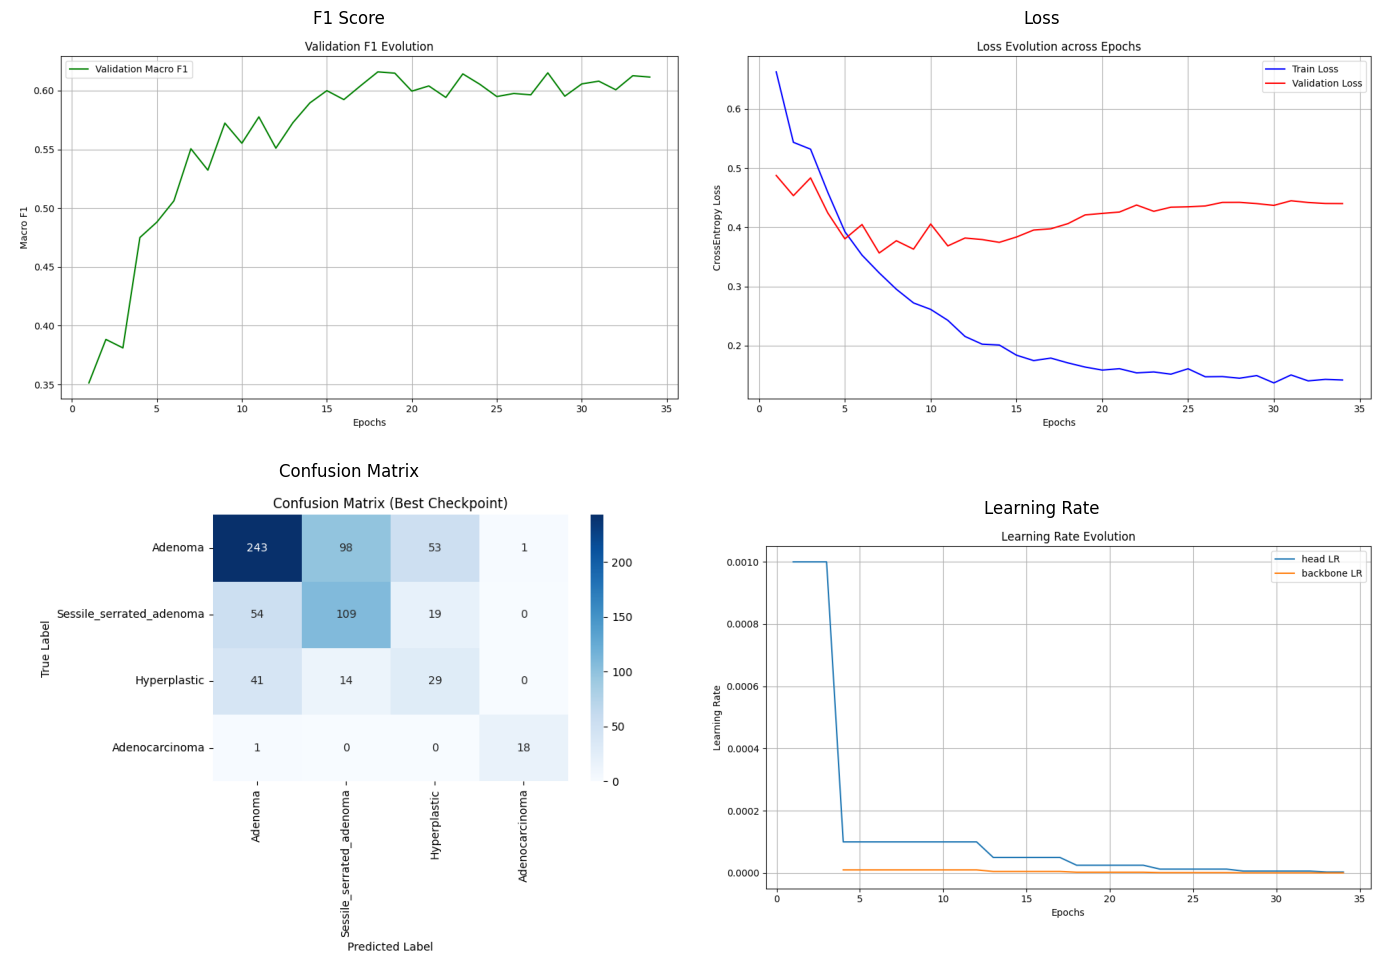

In [8]:
show_phase2_plots(training_config=TRAINING_CONFIG)

In [9]:
print_phase2_summary(training_config=TRAINING_CONFIG)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.6184 +/- 0.0256,0.3478 +/- 0.0266,0.6196 +/- 0.0087,0.6143 +/- 0.0129,0.6297 +/- 0.0056
1,Adenoma,0.6596 +/- 0.0196,0.3095 +/- 0.0300,0.6981 +/- 0.0275,0.7188 +/- 0.0059,0.6797 +/- 0.0489
2,Sessile_serrated_adenoma,0.7452 +/- 0.0180,0.3835 +/- 0.0359,0.5591 +/- 0.0237,0.5215 +/- 0.0296,0.6030 +/- 0.0197
3,Hyperplastic,0.8368 +/- 0.0170,0.2141 +/- 0.0166,0.3036 +/- 0.0144,0.3266 +/- 0.0345,0.2887 +/- 0.0405
4,Adenocarcinoma,0.9952 +/- 0.0014,0.9158 +/- 0.0228,0.9176 +/- 0.0226,0.8904 +/- 0.0430,0.9474 +/- 0.0000


In [10]:
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in PHASE2_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in PHASE2_RUNS],
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4554 +/- 0.0070,0.3071 +/- 0.0157,0.3695 +/- 0.0007,0.4566 +/- 0.0090,0.4646 +/- 0.0221
1,Adenoma,0.6649 +/- 0.0036,0.3171 +/- 0.0211,0.5483 +/- 0.0143,0.4540 +/- 0.0048,0.6925 +/- 0.0380
2,Sessile_serrated_adenoma,0.7600 +/- 0.0079,0.0742 +/- 0.0204,0.0575 +/- 0.0080,0.0305 +/- 0.0042,0.5000 +/- 0.0786
3,Hyperplastic,0.6692 +/- 0.0056,0.0589 +/- 0.0079,0.1775 +/- 0.0337,0.4003 +/- 0.0088,0.1152 +/- 0.0274
4,Adenocarcinoma,0.8168 +/- 0.0088,0.6187 +/- 0.0230,0.6947 +/- 0.0134,0.9415 +/- 0.0259,0.5505 +/- 0.0088
